# Анализ воронки активации и результатов A/B-тестирования в SaaS
**Предметная область:** Платформа для дистрибуции звуковых плагинов и облачного мастеринга.
**Цель:** Найти Aha-момент и оценить влияние нового интерактивного онбординга на конверсию в платную подписку.

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Подключаем наши модули из папки src
sys.path.append('../')
from src.data_generator import generate_synthetic_data
from src.stats_utils import calculate_funnel_metrics, prepare_user_features, estimate_logistic_regression, run_z_test

# Настройка внешнего вида графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [4]:
data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
file_path = os.path.join(data_dir, 'events_log.csv')

if not os.path.exists(file_path):
    print("Генерация новых данных...")
    df_events = generate_synthetic_data(n_users=2000)
    df_events.to_csv(file_path, index=False)
else:
    df_events = pd.read_csv(file_path)

print(f"Загружено событий: {len(df_events)}")
df_events.head()

Загружено событий: 23233


,user_id,event,timestamp
0,user_0902,1_registration,2026-01-01 00:02:00
1,user_0902,2_download_installer,2026-01-01 00:06:00
2,user_0380,1_registration,2026-01-01 00:07:00
3,user_1278,1_registration,2026-01-01 00:16:00
4,user_1278,2_download_installer,2026-01-01 00:20:00


,Step,Unique_Users,CR_to_Base_%,Conversion_from_Previous_%,Drop_off_Rate_%
0,1_registration,2000,100.00,100.00,0.00
1,2_download_installer,1685,84.25,84.25,15.75
2,3_plugin_open,1267,63.35,75.19,24.81
3,4_preset_change,1267,63.35,100.00,0.00
4,5_ai_assistant_click,432,21.60,34.10,65.90
5,6_audio_export,979,48.95,226.62,-126.62
6,7_subscription_purchase,166,8.30,16.96,83.04


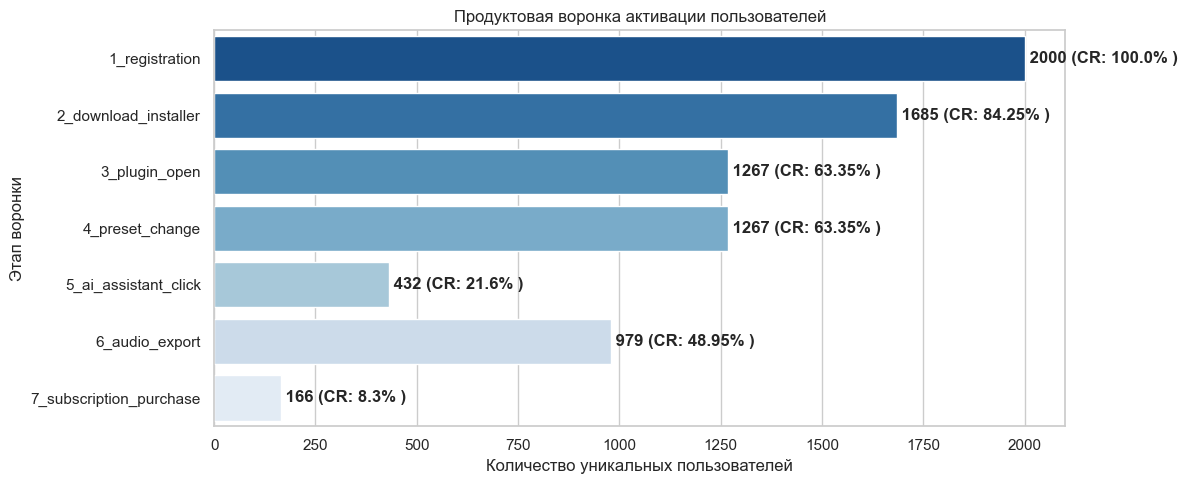

In [6]:
funnel = calculate_funnel_metrics(df_events, total_users=2000)
display(funnel)

plt.figure(figsize=(12, 5))
# Строим график. Обрати внимание: добавлен hue='Step', чтобы избежать предупреждений
sns.barplot(x='Unique_Users', y='Step', data=funnel, hue='Step', palette='Blues_r', legend=False)

for index, value in enumerate(funnel['Unique_Users']):
    plt.text(value, index, f" {value} (CR: {funnel.loc[index, 'CR_to_Base_%']}% )", va='center', fontweight='bold')

plt.title('Продуктовая воронка активации пользователей')
plt.xlabel('Количество уникальных пользователей')
plt.ylabel('Этап воронки')
plt.tight_layout()
plt.show()


In [7]:
print("Поиск Aha-момента (Логистическая регрессия)")
df_features = prepare_user_features(df_events)
model = estimate_logistic_regression(df_features)
display(model.summary2().tables[1])

# Вывод: Факторы ai_assistant_used и audio_exports имеют p-value < 0.05, 
# что делает их статистически значимыми триггерами для покупки подписки.

Поиск Aha-момента (Логистическая регрессия)


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-3.611014,0.202981,-17.789948,8.455827e-71,-4.008849,-3.213179
presets_changed,0.015868,0.009901,1.602610,1.090207e-01,-0.003538,0.035274
ai_assistant_used,1.772610,0.209152,8.475235,2.346052e-17,1.362680,2.182540
audio_exports,0.231353,0.051400,4.500992,6.763712e-06,0.130610,0.332096


In [8]:
# Смоделируем результаты эксперимента (Группа А - старый дизайн, Группа В - новый онбординг)
np.random.seed(42)
n_ab = 1500

success_A = np.random.binomial(n_ab, 0.075) # Конверсия около 7.5%
success_B = np.random.binomial(n_ab, 0.110) # Конверсия около 11%

stat, p_val = run_z_test(success_A, n_ab, success_B, n_ab)

print(f"Группа A (Контроль): Сэмпл={n_ab}, Конверсий={success_A}, CR={success_A/n_ab:.4%}")
print(f"Группа B (Тест):    Сэмпл={n_ab}, Конверсий={success_B}, CR={success_B/n_ab:.4%}")
print(f"Z-статистика: {stat:.4f}")
print(f"p-value: {p_val:.5f}")

if p_val < 0.05:
    print("\nРезультат: Отклоняем нулевую гипотезу! Эффект статистически значим. Внедряем новый онбординг.")
else:
    print("\nРезультат: Не удалось отклонить нулевую гипотезу. Эффект отсутствует.")

Группа A (Контроль): Сэмпл=1500, Конверсий=107, CR=7.1333%
Группа B (Тест):    Сэмпл=1500, Конверсий=167, CR=11.1333%
Z-статистика: 3.8025
p-value: 0.00007

Результат: Отклоняем нулевую гипотезу! Эффект статистически значим. Внедряем новый онбординг.
